# Model Experiment for House Prices Assignment
This notebook contains the complete pipeline: data cleaning, feature engineering, feature selection, model training, and MLflow tracking.

## 1. Setup
Import libraries and initialize MLflow tracking.

In [99]:
import numpy as np
import pandas as pd
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, skew
import dagshub

dagshub.init(repo_owner='Sula1909', repo_name='ML-Assignment1', mlflow=True)

mlflow.set_tracking_uri("https://dagshub.com/Sula1909/ML-Assignment1.mlflow")

mlflow.set_experiment("Assignment1-House_Prices")

Initialized MLflow to track repo "Sula1909/ML-Assignment1"

Repository Sula1909/ML-Assignment1 initialized!

<Experiment: artifact_location='mlflow-artifacts:/8c9fdcb0bce34878a3272e4fb3a48420', creation_time=1776117705816, experiment_id='1', last_update_time=1776117705816, lifecycle_stage='active', name='Assignment1-House_Prices', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [100]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.expand_frame_repr', False)

## 2. Data Loading and Inspection
Load the training and test data, inspect basic shape and preview samples.

In [101]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

train.shape
test.shape


(1459, 80)

In [102]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [103]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [104]:
#Save the 'Id' column
train_ID = train['Id']
test_ID = test['Id']

train.drop("Id", axis = 1, inplace = True)
test.drop("Id", axis = 1, inplace = True)

train.shape
test.shape

(1459, 79)

In [105]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [106]:
na_rate = train.isna().mean()
print(na_rate[na_rate > 0].sort_values(ascending=False).to_string())

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
BsmtExposure    0.026027
BsmtFinType2    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685


## 3. Data Cleaning
Inspect missing values, remove outliers, and transform the target distribution for better modeling.

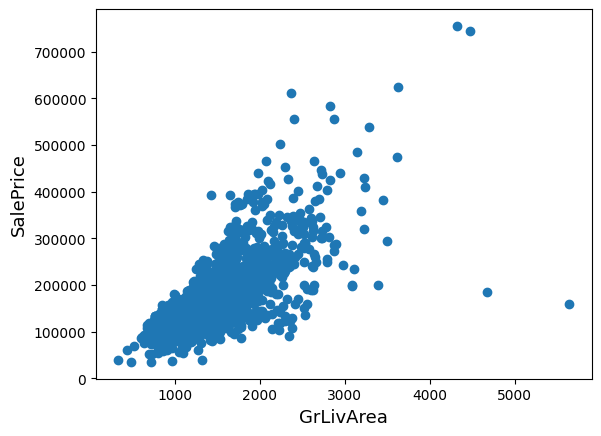

In [107]:
fig, ax = plt.subplots()
ax.scatter(x = train['GrLivArea'], y = train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

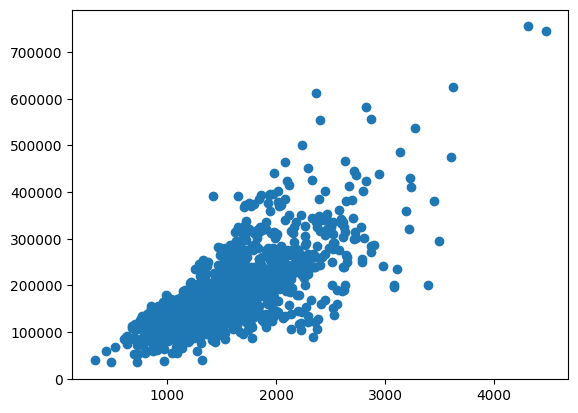

In [108]:
#Removing outliers
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

fig, ax = plt.subplots()
ax.scatter(train['GrLivArea'], train['SalePrice'])
plt.show()


 mu = 180932.92 and sigma = 79467.79



<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\KOBA\AppData\Local\Temp\ipykernel_5836\1352430211.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
C:\Users\KOBA\AppData\Local\Temp\ipykernel_5836\1352430211.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.

Text(0.5, 1.0, 'SalePrice distribution')

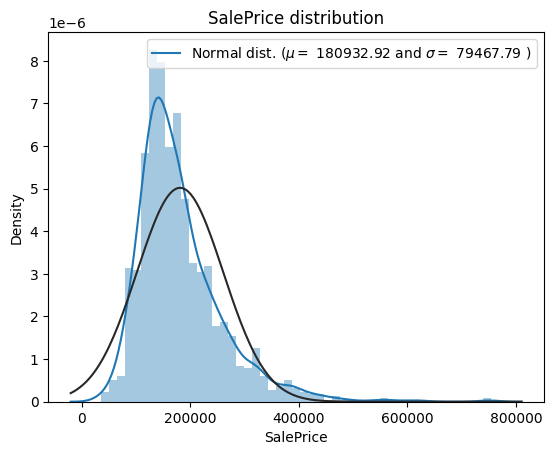

In [109]:
sns.distplot(train['SalePrice'] , fit=norm);

(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.title('SalePrice distribution')

## 4. Target Distribution and Transformation
Review and normalize the SalePrice target distribution to improve model performance.

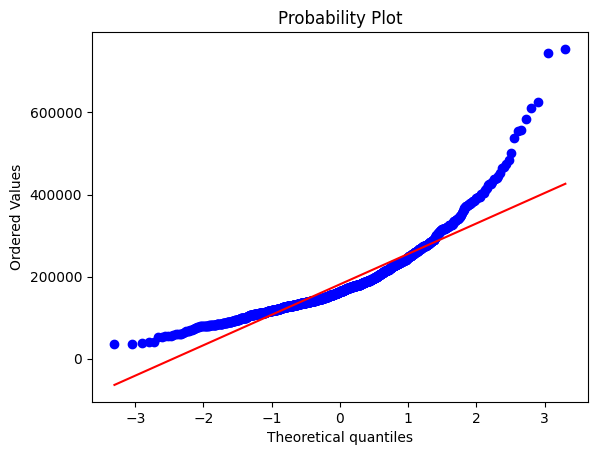

In [110]:
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()


 mu = 12.02 and sigma = 0.40



<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\KOBA\AppData\Local\Temp\ipykernel_5836\2108666143.py:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
C:\Users\KOBA\AppData\Local\Temp\ipykernel_5836\2108666143.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gi

Text(0.5, 1.0, 'SalePrice distribution')

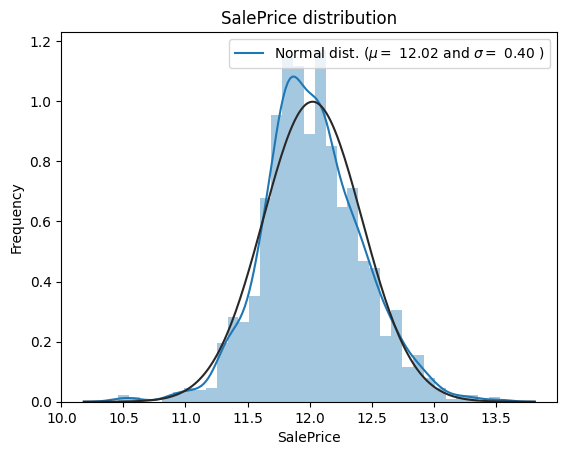

In [111]:
 # log(1 + x) transformation
train["SalePrice"] = np.log1p(train["SalePrice"])

 # New graph
sns.distplot(train['SalePrice'] , fit=norm);

(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
             loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

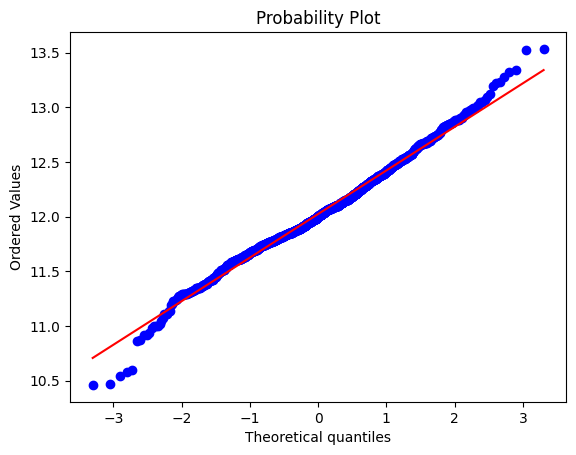

In [112]:
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

In [113]:
na_rate = train.isna().mean()
print(na_rate[na_rate > 0].sort_values(ascending=False).to_string())

PoolQC          0.995885
MiscFeature     0.962963
Alley           0.937586
Fence           0.807270
MasVnrType      0.598080
FireplaceQu     0.473251
LotFrontage     0.177641
GarageType      0.055556
GarageYrBlt     0.055556
GarageFinish    0.055556
GarageQual      0.055556
GarageCond      0.055556
BsmtExposure    0.026063
BsmtFinType2    0.026063
BsmtQual        0.025377
BsmtCond        0.025377
BsmtFinType1    0.025377
MasVnrArea      0.005487
Electrical      0.000686


## 5. Feature Engineering
Combine train and test data for consistent preprocessing, add new features, and encode categorical values.

In [114]:
ntrain = train.shape[0]
ntest = test.shape[0] 

y_train = train.SalePrice.values

all_data = pd.concat((train, test)).reset_index(drop=True)
na_rate = all_data.isna().mean()
print(na_rate[na_rate > 0].sort_values(ascending=False).to_string())

PoolQC          0.996915
MiscFeature     0.964004
Alley           0.932122
Fence           0.804251
MasVnrType      0.605417
SalePrice       0.500171
FireplaceQu     0.486802
LotFrontage     0.166610
GarageQual      0.054508
GarageYrBlt     0.054508
GarageFinish    0.054508
GarageCond      0.054508
GarageType      0.053822
BsmtCond        0.028111
BsmtExposure    0.028111
BsmtQual        0.027768
BsmtFinType2    0.027425
BsmtFinType1    0.027083
MasVnrArea      0.007885
MSZoning        0.001371
Utilities       0.000686
Functional      0.000686
BsmtHalfBath    0.000686
BsmtFullBath    0.000686
BsmtFinSF1      0.000343
Exterior2nd     0.000343
Exterior1st     0.000343
Electrical      0.000343
TotalBsmtSF     0.000343
BsmtUnfSF       0.000343
BsmtFinSF2      0.000343
GarageCars      0.000343
KitchenQual     0.000343
GarageArea      0.000343
SaleType        0.000343


Text(0.5, 1.0, 'Data missing percent by feature')

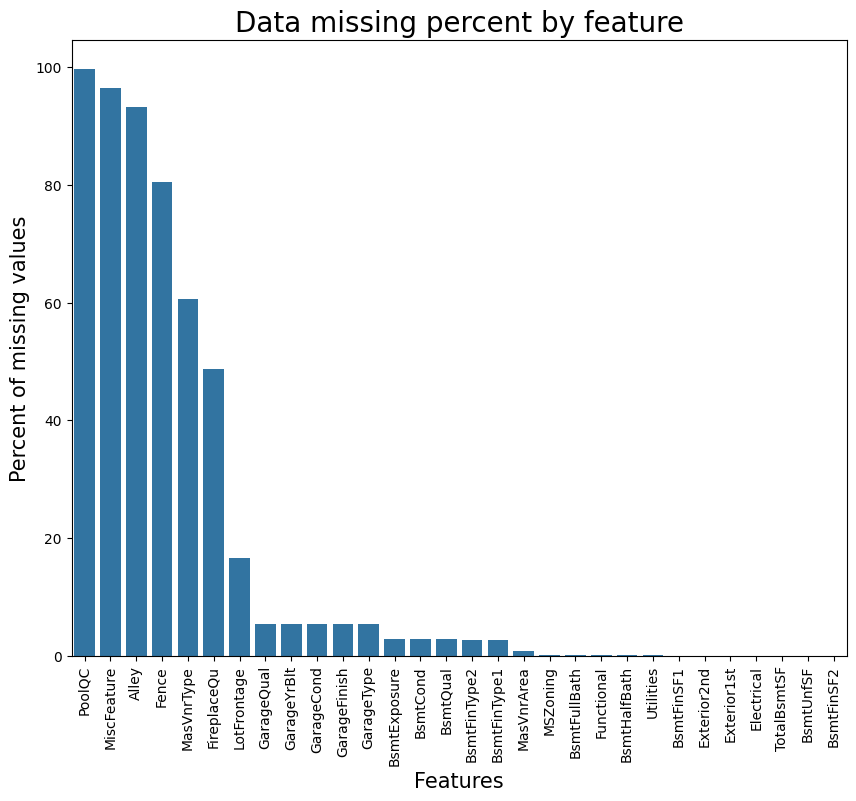

In [115]:
y_train = train.SalePrice.values
all_data.drop(['SalePrice'], axis=1, inplace=True)

all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]

f, ax = plt.subplots(figsize=(10, 8))
plt.xticks(rotation='vertical')
sns.barplot(x=all_data_na.index, y=all_data_na)
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Data missing percent by feature', fontsize=20)

<Axes: >

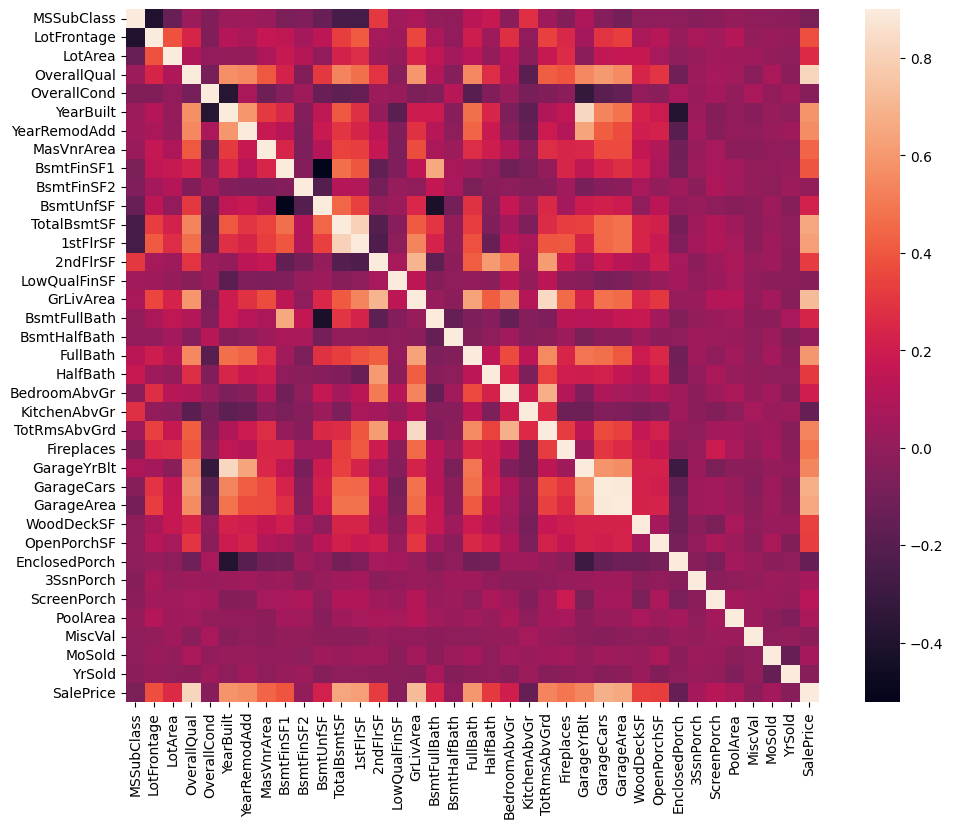

In [116]:
#Correlation map with SalePrice
corrmat = train.select_dtypes(include=[np.number]).corr()
plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax=0.9, square=True)

In [117]:
all_data["PoolQC"] = all_data["PoolQC"].fillna("None")
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")


In [118]:
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    all_data[col] = all_data[col].fillna('None')

In [119]:
# no garage => 0 cars
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_data[col] = all_data[col].fillna(0)

In [120]:
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

In [121]:
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')

In [122]:
all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)

In [123]:
counts = all_data.nunique().sort_values(ascending=True).head(30)
print(counts)

Street          2
Utilities       2
CentralAir      2
LandSlope       3
BsmtHalfBath    3
HalfBath        3
Alley           3
PavedDrive      3
BsmtFullBath    4
KitchenAbvGr    4
KitchenQual     4
GarageFinish    4
MasVnrType      4
LotShape        4
ExterQual       4
LandContour     4
PoolQC          4
BsmtQual        5
HeatingQC       5
BsmtCond        5
ExterCond       5
FullBath        5
BsmtExposure    5
Electrical      5
MSZoning        5
LotConfig       5
Fireplaces      5
YrSold          5
Fence           5
MiscFeature     5
dtype: int64


In [124]:
all_data = all_data.drop(['Utilities'], axis=1)

In [125]:
#modati chanacvleba

all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])

all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])

all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])

all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])

In [126]:
#Pirobis tanaxmad
all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

all_data["Functional"] = all_data["Functional"].fillna("Typ")

all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

In [127]:
#Check NA
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_data.head()

,Missing Ratio
LotFrontage,16.660953


In [128]:
# Samezoblos mediana!
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

In [129]:
#Check NA
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_data.head()

,Missing Ratio


In [130]:
#Fake intebi gadagvkavs kategoriulshi
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)

all_data['OverallCond'] = all_data['OverallCond'].astype(str)

all_data['YrSold'] = all_data['YrSold'].astype(str)

all_data['MoSold'] = all_data['MoSold'].astype(str)

In [131]:
#Columnebshi mnishvnelobebis ierarkia sheidzleba daarhgvios, magram still good enough
from sklearn.preprocessing import LabelEncoder
cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold')
for c in cols:
    lbl = LabelEncoder() 
    lbl.fit(list(all_data[c].values)) 
    all_data[c] = lbl.transform(list(all_data[c].values))

In [132]:
all_data.shape

(2917, 78)

In [133]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

## 6. Feature Selection
Use correlation analysis to select the most relevant features and reduce noise before training.

In [134]:
all_data = pd.get_dummies(all_data)

In [135]:
all_data.shape

(2917, 220)

In [136]:
train = all_data[:ntrain]
test = all_data[ntrain:]

In [137]:
train.shape
test.shape

(1459, 220)

In [138]:
# Kernel Ridgeze Feature Selections gareshe uketesi shedegi momca, amitom am konkretul models ar gavukete Feature Selection corelaciit.


# Feature Selection using Correlation Analysis
temp_train = train.copy()
temp_train['SalePrice'] = y_train

correlations = temp_train.corr()['SalePrice'].abs().sort_values(ascending=False)
print("Top 20 correlations with SalePrice:")
print(correlations.head(20))

# Select features with correlation > 0.1
selected_features = correlations[correlations > 0.1].index.tolist()
selected_features.remove('SalePrice')

print(f"\nSelected {len(selected_features)} features out of {train.shape[1]}")

train = train[selected_features]
test = test[selected_features]

print(f"New train shape: {train.shape}")
print(f"New test shape: {test.shape}")

Top 20 correlations with SalePrice:
SalePrice           1.000000
TotalSF             0.825326
OverallQual         0.821405
GrLivArea           0.725211
GarageCars          0.681033
GarageArea          0.656129
TotalBsmtSF         0.647563
1stFlrSF            0.620500
FullBath            0.595899
ExterQual           0.587214
YearBuilt           0.587043
BsmtQual            0.578564
YearRemodAdd        0.565992
TotRmsAbvGrd        0.537702
KitchenQual         0.537038
Foundation_PConc    0.531194
Fireplaces          0.491998
MasVnrArea          0.430570
HeatingQC           0.426052
GarageFinish        0.417961
Name: SalePrice, dtype: float64

Selected 107 features out of 220
New train shape: (1458, 107)
New test shape: (1459, 107)


# 7. Model Training

Train models and evaluate performance with MLflow logging. Include different approaches for comparison.


In [ ]:
# from sklearn.linear_model import Lasso
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(train) 

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#     X_train_scaled, y_train, test_size=0.2, random_state=42
# )

# with mlflow.start_run(run_name="Lasso_Final_0.001"):
    
#     lasso_model = Lasso(alpha=0.001, max_iter=10000) 
#     lasso_model.fit(X_train_split, y_train_split)
    
#     preds = lasso_model.predict(X_val_split)

#     used_features = sum(lasso_model.coef_ != 0)
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     mae = mean_absolute_error(y_val_split, preds)
#     r2 = r2_score(y_val_split, preds)

#     # MLflow logging
#     mlflow.log_param("model_type", "Lasso")
#     mlflow.log_param("alpha", 0.001)
#     mlflow.log_param("features_used", used_features)
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)

#     mlflow.sklearn.log_model(lasso_model, artifact_path="Lasso_model", registered_model_name="HousePrices_Lasso")
    
#     print(f"Used Features: {used_features}")
#     print(f"RMSE : {rmse:.4f}")

2026/04/15 18:46:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 18:46:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'HousePrices_Lasso'.
2026/04/15 18:47:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Lasso, version 1
Created version '1' of model 'HousePrices_Lasso'.


Used Features: 81
RMSE : 0.1242
🏃 View run Lasso_Final_0.001 at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1/runs/ed1d409363a74f7e8f03e1d26ffe7f4a
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1


In [ ]:
# from sklearn.linear_model import Lasso
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import mlflow
# import mlflow.sklearn
# import numpy as np

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(train) 

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#     X_train_scaled, y_train, test_size=0.2, random_state=42
# )

# with mlflow.start_run(run_name="Lasso_Final_0.01"):
#     lasso_model = Lasso(alpha=0.01, max_iter=10000) 
#     lasso_model.fit(X_train_split, y_train_split)
    
#     preds = lasso_model.predict(X_val_split)

#     used_features = sum(lasso_model.coef_ != 0)
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     mae = mean_absolute_error(y_val_split, preds)
#     r2 = r2_score(y_val_split, preds)

#     mlflow.log_param("model_type", "Lasso")
#     mlflow.log_param("alpha", 0.01)
#     mlflow.log_param("features_used", used_features)
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)

#     mlflow.sklearn.log_model(lasso_model, artifact_path="Lasso_model", registered_model_name="HousePrices_Lasso")
    
#     print(f"Alpha: 0.01")
#     print(f"Used Features: {used_features}")
#     print(f"RMSE : {rmse:.4f}")

2026/04/15 18:56:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 18:57:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_Lasso' already exists. Creating a new version of this model...
2026/04/15 18:57:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_Lasso, version 2
Created version '2' of model 'HousePrices_Lasso'.


Alpha: 0.01
Used Features: 42
RMSE : 0.1295
🏃 View run Lasso_Final_0.01 at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1/runs/94506bc6ccfe4230b374e843523ce854
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1


In [ ]:
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(train, y_train, test_size=0.2, random_state=42)

# with mlflow.start_run(run_name="Kernel_Ridge"):
    
   
#     model = KernelRidge(alpha=0.1, kernel='poly', degree=2) 
#     model.fit(X_train_split, y_train_split)
    
#     preds = model.predict(X_val_split)
    
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     mae = mean_absolute_error(y_val_split, preds)
#     r2 = r2_score(y_val_split, preds)
    
#     mlflow.log_param("model_type", "KernelRidge")
#     mlflow.log_param("alpha", 0.1)
#     mlflow.log_param("kernel", "poly")
#     mlflow.log_param("degree", 2)
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)
    
#     print(f"RMSE: {rmse:.4f}")
#     print(f"MAE : {mae:,.2f}$")
#     print(f"R2: {r2:.4f}")

In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(train, y_train, test_size=0.2, random_state=42)

# # !!!
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_split)
# X_val_scaled = scaler.transform(X_val_split)

# with mlflow.start_run(run_name="Kernel_Ridge_Scaled_NoFeatureSelection"):
    
#     model = KernelRidge(alpha=1.0, kernel='poly', degree=2) 
#     model.fit(X_train_scaled, y_train_split)
    
#     preds = model.predict(X_val_scaled)
    
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     r2 = r2_score(y_val_split, preds)
#     mae = mean_absolute_error(y_val_split, preds)
    
#     mlflow.log_param("model_type", "KernelRidge")
#     mlflow.log_param("alpha", 1.0)
#     mlflow.log_param("kernel", "poly")
#     mlflow.log_param("degree", 2)
#     mlflow.log_param("scaled", "True")
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)

#     mlflow.sklearn.log_model(model, artifact_path="kernel_ridge_model")
    
#     print(f"Scaled Kernel Ridge RMSE: {rmse:.4f}")
#     print(f"Scaled Kernel Ridge MAE: {mae:,.2f}$")
#     print(f"Scaled Kernel Ridge R2: {r2:.4f}")

In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(train, y_train, test_size=0.2, random_state=42)

# with mlflow.start_run(run_name="Decision_Tree_Depth_10"):
    
#     model = DecisionTreeRegressor(random_state=42, max_depth=10)  # Adjust hyperparameters as needed
#     model.fit(X_train_split, y_train_split)
    
#     preds = model.predict(X_val_split)
    
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     mae = mean_absolute_error(y_val_split, preds)
#     r2 = r2_score(y_val_split, preds)
    
#     mlflow.log_param("model_type", "DecisionTreeRegressor")
#     mlflow.log_param("max_depth", 10)
#     mlflow.log_param("random_state", 42)
#     mlflow.log_param("features_selected", len(selected_features))

#     mlflow.log_artifact("model_experiment.ipynb")
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)
    
#     print(f"Decision Tree RMSE: {rmse:.4f}")
#     print(f"Decision Tree MAE: {mae:,.2f}$")
#     print(f"Decision Tree R2: {r2:.4f}")

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Hyperparameter tuning for Decision Tree
# param_grid = {
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
# grid_search.fit(X_train_split, y_train_split)

# best_model = grid_search.best_estimator_
# print(f"Best params: {grid_search.best_params_}")

# best_preds = best_model.predict(X_val_split)
# best_rmse = np.sqrt(mean_squared_error(y_val_split, best_preds))
# best_mae = mean_absolute_error(y_val_split, best_preds)
# best_r2 = r2_score(y_val_split, best_preds)

# print(f"Best Decision Tree RMSE: {best_rmse:.4f}")
# print(f"Best Decision Tree MAE: {best_mae:.4f}")
# print(f"Best Decision Tree R2: {best_r2:.4f}")

# with mlflow.start_run(run_name="Decision_Tree_Tuned"):
#     mlflow.log_params(grid_search.best_params_)
#     mlflow.log_param("model_type", "DecisionTreeRegressor_Tuned")
#     mlflow.log_metric("rmse", best_rmse)
#     mlflow.log_metric("mae", best_mae)
#     mlflow.log_metric("r2_score", best_r2)

#     mlflow.log_artifact("model_experiment.ipynb")

#     mlflow.sklearn.log_model(best_model, artifact_path="best_decision_tree_model", registered_model_name="HousePrices_DecisionTree_Tuned")

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Decision Tree RMSE: 0.2016
Best Decision Tree MAE: 0.1360
Best Decision Tree R2: 0.7589


2026/04/15 19:27:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:27:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'HousePrices_DecisionTree_Tuned'.
2026/04/15 19:27:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_DecisionTree_Tuned, version 1
Created version '1' of model 'HousePrices_DecisionTree_Tuned'.


🏃 View run Decision_Tree_Tuned at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1/runs/4ddffde8a5d44066ad6b6a6ab9f97f1f
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1


In [ ]:
# from sklearn.ensemble import RandomForestRegressor

# # Try Random Forest for better performance
# rf_param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [10, 15, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# rf_grid_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring='neg_mean_squared_error')
# rf_grid_search.fit(X_train_split, y_train_split)

# rf_best_model = rf_grid_search.best_estimator_
# print(f"Best RF params: {rf_grid_search.best_params_}")

# rf_preds = rf_best_model.predict(X_val_split)
# rf_rmse = np.sqrt(mean_squared_error(y_val_split, rf_preds))
# rf_mae = mean_absolute_error(y_val_split, rf_preds)
# rf_r2 = r2_score(y_val_split, rf_preds)

# print(f"Random Forest RMSE: {rf_rmse:.4f}")
# print(f"Random Forest MAE: {rf_mae:.4f}")
# print(f"Random Forest R2: {rf_r2:.4f}")

# with mlflow.start_run(run_name="Random_Forest_Tuned"):
#     mlflow.log_params(rf_grid_search.best_params_)
#     mlflow.log_param("model_type", "RandomForestRegressor_Tuned")
#     mlflow.log_metric("rmse", rf_rmse)
#     mlflow.log_metric("mae", rf_mae)
#     mlflow.log_metric("r2_score", rf_r2)

#     mlflow.log_artifact("model_experiment.ipynb")

#     mlflow.sklearn.log_model(rf_best_model, artifact_path="random_forest_model", registered_model_name="HousePrices_RF")

Best RF params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest RMSE: 0.1456
Random Forest MAE: 0.0967
Random Forest R2: 0.8743


2026/04/15 19:10:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:10:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'HousePrices_RF'.
2026/04/15 19:10:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_RF, version 1
Created version '1' of model 'HousePrices_RF'.


🏃 View run Random_Forest_Tuned at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1/runs/55ce6c2871e641c4babd1c6c788d594a
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(train, y_train, test_size=0.2, random_state=42)

# with mlflow.start_run(run_name="XGBoost_Changed"):
    
#     model = XGBRegressor(random_state=42, n_estimators=200, max_depth=8, learning_rate=0.1, subsample=0.8)  # Tuned params
#     model.fit(X_train_split, y_train_split)
    
#     preds = model.predict(X_val_split)
    
#     rmse = np.sqrt(mean_squared_error(y_val_split, preds))
#     mae = mean_absolute_error(y_val_split, preds)
#     r2 = r2_score(y_val_split, preds)
    
#     mlflow.log_param("model_type", "XGBRegressor")
#     mlflow.log_param("n_estimators", 200)
#     mlflow.log_param("max_depth", 8)
#     mlflow.log_param("learning_rate", 0.1)
#     mlflow.log_param("subsample", 0.8)
#     mlflow.log_param("random_state", 42)

#     mlflow.log_artifact("model_experiment.ipynb")
    
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("r2_score", r2)
    
#     print(f"XGBoost RMSE: {rmse:.4f}")
#     print(f"XGBoost MAE: {mae:.4f}")
#     print(f"XGBoost R2: {r2:.4f}")

In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.model_selection import GridSearchCV

# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(train, y_train, test_size=0.2, random_state=42)

# xgb_param_grid = {
#     'n_estimators': [200, 300],
#     'max_depth': [6, 8, 10],
#     'learning_rate': [0.1, 0.05],
#     'subsample': [0.8, 1.0]
# }

# xgb_grid_search = GridSearchCV(XGBRegressor(random_state=42), xgb_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
# xgb_grid_search.fit(X_train_split, y_train_split)

# xgb_best_model = xgb_grid_search.best_estimator_
# print(f"Best XGBoost params: {xgb_grid_search.best_params_}")

# xgb_preds = xgb_best_model.predict(X_val_split)
# xgb_rmse = np.sqrt(mean_squared_error(y_val_split, xgb_preds))
# xgb_mae = mean_absolute_error(y_val_split, xgb_preds)
# xgb_r2 = r2_score(y_val_split, xgb_preds)

# print(f"Tuned XGBoost RMSE: {xgb_rmse:.4f}")
# print(f"Tuned XGBoost MAE: {xgb_mae:.4f}")
# print(f"Tuned XGBoost R2: {xgb_r2:.4f}")

# with mlflow.start_run(run_name="XGBoost_Tuned"):
#     mlflow.log_params(xgb_grid_search.best_params_)
#     mlflow.log_param("model_type", "XGBRegressor_Tuned")

#     mlflow.log_metric("rmse", xgb_rmse)
#     mlflow.log_metric("mae", xgb_mae)
#     mlflow.log_metric("r2_score", xgb_r2)

#     mlflow.log_artifact("model_experiment.ipynb")

#     mlflow.sklearn.log_model(xgb_best_model, artifact_path="XGBoost_model", registered_model_name="HousePrices_XGBoost")

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Tuned XGBoost RMSE: 0.1392
Tuned XGBoost MAE: 0.0936
Tuned XGBoost R2: 0.8850


2026/04/15 18:31:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 18:31:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'HousePrices_XGBoost'.
2026/04/15 18:31:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_XGBoost, version 1
Created version '1' of model 'HousePrices_XGBoost'.


🏃 View run XGBoost_Tuned at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1/runs/fd8c758a2a3840048b0e3f58913fb05e
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment1.mlflow/#/experiments/1
